# Decomposing a fault: cuts, both reduction factors and a location without its electrode

A 20 kV cable feeder with six substations, faulted in the middle. The point
of this example is not the fault solve itself — that is the
[minimal example](minimal.ipynb) — but the analysis layer on top of it:

1. the **two reduction factors** and why they answer different questions,
2. **`analyze_cuts`** — what each direction away from the fault contributes,
3. **`bus_response`** — the whole network response to *any* electrode at the
   faulted station, from two solves,
4. **`run_sweep` + `summarize`/`classify`** — the same study across a range of
   soil resistivities,
5. **`run_reference_cases`** — the closed-form checks the package runs against
   itself.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import polars as pl

import groundinsight as gi
from groundinsight.models.core_models import BusType, BranchType

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(120)

polars.config.Config

## 1. The network

Six substations `S0 … S5`, connected by 1.2 km sections of a 20 kV cable whose
shield-earth loop carries 0.25 Ω/km and 1.9 mH/km, with 0.05 Ω/km and
1.85 mH/km of Carson earth-return mutual coupling to the phase conductor.

`phase_impedance_formula` describes the **phase** conductor — the faulted one
whose current induces the longitudinal EMF on the shield. It never enters the
nodal admittance matrix; it is what the automatic phase-current distribution
solves on. On a radial feeder like this one the phase current is unambiguous
either way, but declaring it costs nothing and makes the model honest if a ring
is closed later.

In [2]:
TWO_PI = 2 * 3.141592653589793
FREQS = [50.0]
N_BUSES = 6
SECTION_KM = 1.2
I_FAULT = 3000.0          # A, 3*I_0 at the infeed

net = gi.create_network(name="DecompositionDemo", frequencies=FREQS)

station = BusType(
    name="Station",
    system_type="Substation",
    voltage_level=20,
    impedance_formula="rho * 0.02",
)
cable = BranchType(
    name="NA2XS2Y-1x300",
    grounding_conductor=True,
    self_impedance_formula=f"(0.25 + j * f * 1.9e-3 * {TWO_PI}) * l",
    mutual_impedance_formula=f"(0.05 + j * f * 1.85e-3 * {TWO_PI}) * l",
    phase_impedance_formula=f"(0.10 + j * f * 0.4e-3 * {TWO_PI}) * l",
)

for i in range(N_BUSES):
    gi.create_bus(name=f"S{i}", type=station, network=net)
for i in range(N_BUSES - 1):
    gi.create_branch(
        name=f"C{i}{i + 1}", type=cable,
        from_bus=f"S{i}", to_bus=f"S{i + 1}",
        length=SECTION_KM, network=net,
    )

gi.create_source(name="infeed", bus="S0", values={50.0: I_FAULT}, network=net)
gi.create_fault(name="mid", bus="S3", scalings={50.0: 1.0}, network=net)

gi.run_fault(network=net, fault_name="mid")
net.res_all_impedances()

fault_name,fault_bus,frequency_Hz,grounding_impedance_Ohm,grounding_impedance_deg,reduction_factor,reduction_factor_current
str,str,f64,f64,f64,f64,f64
"""mid""","""S3""",50.0,0.615672,1.466513,0.310003,0.191365


## 2. Two reduction factors, two questions

`reduction_factor` is the EPR-based one: the same system is solved twice, once
with the mutual Norton sources and once without, and the quotient is taken at
the fault bus. It keeps the meaning of the closed form $r = |1 - Z_m/Z_s|$.

`reduction_factor_current` is the share of the fault current that returned
through **earth** rather than through the shields — $|I_E| / |3 I_0|$, the
quantity EN 50522 means, and the one that closes the chain
$U_E = 3 I_0 \cdot Z_E \cdot r$ on the reported $Z_E$.

The result also carries the split itself, so it can be inspected rather than
trusted: `earth_buses` names the group whose electrode currents were summed,
anchored on the fault bus.

Two quantities are easy to confuse here, so the cell prints both. $U_E$ is
`u_earthing` — the earthing voltage the bonded system as a whole drives against
remote earth, which is what the norm's chain closes on. The **EPR at the fault
bus** is a different, local number and is larger here. Taking the bus EPR for
$U_E$ is the mistake the separate field exists to prevent.

In [3]:
rf = net.results["mid"].reduction_factor

print(f"reduction_factor          (EPR)     = {rf.value[50.0]:.6f}")
print(f"reduction_factor_current  (EN 50522) = {rf.value_current[50.0]:.6f}")
print(f"I_E                                  = {abs(rf.i_earth[50.0]):.1f} A")
print(f"earth_buses                          = {rf.earth_buses[50.0]}")

z_e = abs(complex(rf.z_earthing[50.0]))
u_e = abs(complex(rf.u_earthing[50.0]))
epr_fault_bus = next(b for b in net.results["mid"].buses if b.name == "S3").uepr

print()
print(f"Z_E  (z_earthing)                    = {z_e:.4f} ohm")
print(f"U_E  (u_earthing)                    = {u_e:.2f} V")
print(f"3*I_0 * Z_E * r                      = {I_FAULT * z_e * rf.value_current[50.0]:.2f} V   <- closes on U_E")
print()
print(f"EPR at the fault bus S3              = {epr_fault_bus:.2f} V   <- a different quantity")

# z_earthing is the same number the impedance frame reports as Z_E.
assert abs(z_e - abs(complex(net.results["mid"].grounding_impedance.value[50.0]))) < 1e-12

reduction_factor          (EPR)     = 0.310003
reduction_factor_current  (EN 50522) = 0.191365
I_E                                  = 574.1 A
earth_buses                          = ['S2', 'S3', 'S4', 'S5']

Z_E  (z_earthing)                    = 0.6157 ohm
U_E  (u_earthing)                    = 353.46 V
3*I_0 * Z_E * r                      = 353.46 V   <- closes on U_E

EPR at the fault bus S3              = 500.17 V   <- a different quantity


## 3. Splitting the network at the fault

A `Cut` is a named set of branches, all incident to the fault bus. The analysis
reports what each direction contributes:

    parallel impedance left --- fault location --- parallel impedance right

`Z_side` comes from **source-free current division**: one ampere is injected at
the fault bus with all sources and mutual injections removed, and the share
leaving through each cut gives $Z_{side} = u_{fault} / i_{cut}$. The
decomposition closes by construction — $1/Z_{dp} = 1/Z_{local} +
\sum 1/Z_{side}$: the side admittances and the local one add up to the
driving-point admittance of the whole network.

Note `sides_are_disjoint`: only when the directions do not reach around into
one another do the per-side current quantities have an unambiguous meaning.

In [4]:
towards_infeed = gi.Cut(
    name="towards_infeed", branches=["C23"],
    description="S3 -> S2 -> S1 -> S0, the direction the source feeds from",
)
towards_end = gi.Cut(
    name="towards_open_end", branches=["C34"],
    description="S3 -> S4 -> S5, the passive tail",
)

cuts = gi.analyze_cuts(net, fault="mid", cuts=[towards_infeed, towards_end])
print("sides_are_disjoint:", cuts.sides_are_disjoint)

frame = cuts.to_polars()
frame.select([
    "cut", "side_buses", "Z_side_Ohm", "I_shield_A", "current_share",
    "I_earth_A", "r_side", "kcl_residual",
])

sides_are_disjoint: True


cut,side_buses,Z_side_Ohm,I_shield_A,current_share,I_earth_A,r_side,kcl_residual
str,str,f64,f64,f64,f64,f64,f64
"""towards_infeed""","""S0, S1, S2""",1.55659,2580.46836,0.860156,533.522334,0.177841,1.5166e-16
"""towards_open_end""","""S4, S5""",1.642401,304.534316,0.101511,304.534316,null,1.5166e-16


The passive tail gets `r_side = None` rather than a division by zero: no source
current enters from that direction, so there is no share to take a ratio of.
`kcl_residual` is the check that the currents at the fault bus actually close.

## 4. Characterising the location, not the electrode

Adding an electrode is a rank-one change to the nodal matrix, so by
Sherman–Morrison every nodal voltage is a Möbius function of its admittance.
**Two solves with the electrode removed therefore determine the response for
every electrode.** `BusResponse.evaluate(z)` and `.sweep([...])` then cost no
solve at all.

`z_network` is the site-independent number the analysis is built around: the
driving-point impedance of everything *except* the local electrode. It is a
property of the location, not of what happens to be installed there.

In [5]:
response = gi.bus_response(net, fault="mid", bus="S3")
z_net = response.z_network[50.0]
print(f"Z_net at S3 = {z_net.real:.4f} {z_net.imag:+.4f}j ohm  (|Z| = {abs(z_net):.4f})")

response.extremes().select([
    "case", "Z_bus_Ohm", "Z_driving_point_Ohm", "EPR_V", "EPR_S0_V", "r_current",
])

Z_net at S3 = 0.6482 +0.4709j ohm  (|Z| = 0.8011)


case,Z_bus_Ohm,Z_driving_point_Ohm,EPR_V,EPR_S0_V,r_current
str,f64,f64,f64,f64,f64
"""open""",null,0.801147,672.649618,755.3298,0.16696
"""ideal""",0.0,0.0,5.6843e-14,927.947731,0.279869
"""worst_passive""",1.363059,0.990247,831.419235,880.311682,0.212123


The three cases are the extremes **of the local quantities**: `open` (no
electrode at all), `ideal` ($Z_B = 0$) and `worst_passive`, which maximises
$|Z_{dp}|$ at the reactive resonance $Y_B = -j\,\mathrm{Im}(1/Z_{net})$. Both
endpoints are exact limits rather than numerical stand-ins — the ideal electrode
in particular, which the solver rejects outright because a zero impedance is not
invertible.

Read them as a bracket for `EPR_V` and `Z_driving_point_Ohm`, and **not** for
the transfer quantities in the same table. `EPR_S0_V` and `r_current` are not
bounded by these three cases: a purely capacitive electrode at S3 — passive, so
inside the same class — drives the EPR at S0 above the `ideal` value. If a study
needs the worst case of a transfer quantity, sweep for it with `.sweep([...])`,
which costs no solve, rather than reading it off `extremes()`.

What the three cases do surface is the direction of the effect, which is easy to
get backwards. An **ideal** electrode at the faulted station drives the potential
rise at the infeed station *up*, not down: grounding the fault location harder
pulls more current through the shields towards it. Over $|Z_B|$ from
$10^{-3}$ to $10^{4}\,\Omega$ the EPR at S0 falls monotonically, so the plot
below is the whole story for that pair.

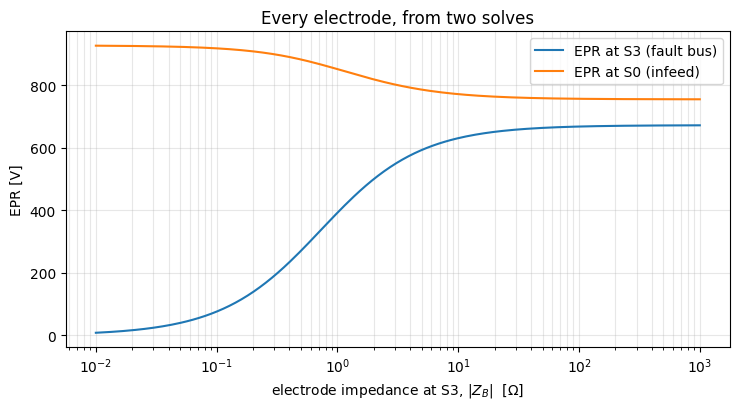

In [6]:
import numpy as np

z_values = np.logspace(-2, 3, 200)
swept = response.sweep([complex(z, 0.0) for z in z_values])
epr_s3 = swept.filter(pl.col("frequency_Hz") == 50.0)["EPR_V"].to_numpy()
epr_s0 = swept.filter(pl.col("frequency_Hz") == 50.0)["EPR_S0_V"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogx(z_values, epr_s3, label="EPR at S3 (fault bus)")
ax.semilogx(z_values, epr_s0, label="EPR at S0 (infeed)")
ax.set_xlabel(r"electrode impedance at S3, $|Z_B|$  [$\Omega$]")
ax.set_ylabel("EPR [V]")
ax.set_title("Every electrode, from two solves")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 5. The same study across soil resistivities

`run_sweep` solves the fault once per parameter point and stacks the results
into long-format frames that carry the parameters as ordinary columns. Anything
a point overrides is undone in a `finally` block, so a failing point leaves
neither the network nor the remaining points contaminated.

This is where the difference between the two reduction factors stops being a
subtlety and becomes the whole answer.

In [7]:
RHOS = [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0]

points = [
    gi.SweepPoint(
        label=f"rho={rho:g}",
        bus_rho={f"S{i}": rho for i in range(N_BUSES)},
        parameters={"rho": rho},
    )
    for rho in RHOS
]

sweep = gi.run_sweep(net, fault="mid", points=points, cuts=[towards_infeed, towards_end])
impedances = sweep.impedances()
impedances.select([
    "rho", "grounding_impedance_Ohm", "reduction_factor", "reduction_factor_current",
])

rho,grounding_impedance_Ohm,reduction_factor,reduction_factor_current
f64,f64,f64,f64
10.0,0.117972,0.310003,0.312025
30.0,0.231931,0.310003,0.280564
100.0,0.615672,0.310003,0.191365
300.0,1.898524,0.310003,0.097349
1000.0,6.551205,0.310003,0.034147
3000.0,19.881615,0.310003,0.011829


`reduction_factor` does not move at all — not approximately, but to six
decimals, sitting exactly on $|1 - Z_m/Z_s| = 0.310003$. **Two separate reasons
coincide here, and they are worth keeping apart:**

1. It is *structurally* blind to the electrode **at the fault bus**. Both solves
   behind it share the same $Y$, so changing the fault-bus admittance is a
   rank-1 update that cancels in the quotient. That holds in any network.
2. This particular sweep changes $\rho$ at **all six** stations, and the
   invariance across all of them is a property of *this* network rather than a
   general one: every branch has the same $Z_m/Z_s$, so the mutual Norton
   vector telescopes along the path to $i_{mut} = -(Z_m/Z_s)\,i_{src}$ and
   $u_{with} = (1 - Z_m/Z_s)\,u_{without}$ at every bus, independent of $Y$.
   Mix cable and overhead-line branches and the same sweep does move `value`.

Either way, a $\rho$ sensitivity study plotted against `value` would be a
horizontal line while the grounding impedance moves two orders of magnitude.
`reduction_factor_current` responds, because it is a current share rather than a
voltage ratio.

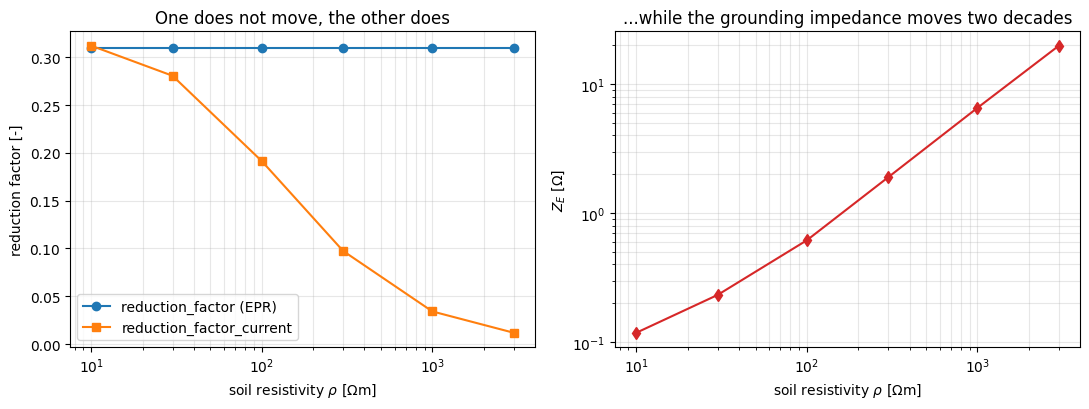

In [8]:
rho = impedances["rho"].to_numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.semilogx(rho, impedances["reduction_factor"], "o-", label="reduction_factor (EPR)")
ax1.semilogx(rho, impedances["reduction_factor_current"], "s-", label="reduction_factor_current")
ax1.set_xlabel(r"soil resistivity $\rho$ [$\Omega$m]")
ax1.set_ylabel("reduction factor [-]")
ax1.set_title("One does not move, the other does")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2.loglog(rho, impedances["grounding_impedance_Ohm"], "d-", color="tab:red")
ax2.set_xlabel(r"soil resistivity $\rho$ [$\Omega$m]")
ax2.set_ylabel(r"$Z_E$ [$\Omega$]")
ax2.set_title("...while the grounding impedance moves two decades")
ax2.grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

`summarize` reduces any numeric column to count, spread, named quantiles and
extremes, grouped or not. `classify` bins a quantity into **user-supplied**
bands — there is deliberately no built-in table of admissible values, because
touch-voltage limits depend on the clearing time, the standard edition and the
assumed additional resistances. The edges come from the caller, who can cite
them.

In [9]:
# sweep.buses() carries one row per frequency *and* an "RMS" row per bus.
# Pooling them would be meaningless as soon as there is more than one
# frequency, so select the band explicitly before summarising.
per_bus = sweep.buses().filter(pl.col("frequency_Hz") == "50")

per_rho = gi.summarize(per_bus, "EPR_V", by=["rho"])
print(per_rho.select(["rho", "n", "mean", "p50", "max"]))

# Edges chosen for this illustration only - substitute the limits your case
# actually has to meet, with the clearing time they belong to.
banded = gi.classify(
    impedances, "grounding_impedance_Ohm",
    edges=[1.0, 5.0], labels=["low", "medium", "high"],
)
banded.select(["rho", "grounding_impedance_Ohm", "class"])

shape: (6, 5)
┌────────┬─────┬────────────┬────────────┬─────────────┐
│ rho    ┆ n   ┆ mean       ┆ p50        ┆ max         │
│ ---    ┆ --- ┆ ---        ┆ ---        ┆ ---         │
│ f64    ┆ u32 ┆ f64        ┆ f64        ┆ f64         │
╞════════╪═════╪════════════╪════════════╪═════════════╡
│ 10.0   ┆ 6   ┆ 66.27616   ┆ 28.519372  ┆ 164.560095  │
│ 30.0   ┆ 6   ┆ 177.928092 ┆ 115.707746 ┆ 398.576222  │
│ 100.0  ┆ 6   ┆ 396.731296 ┆ 336.575913 ┆ 819.129623  │
│ 300.0  ┆ 6   ┆ 592.26538  ┆ 561.989083 ┆ 1192.469498 │
│ 1000.0 ┆ 6   ┆ 685.735006 ┆ 675.769541 ┆ 1373.317677 │
│ 3000.0 ┆ 6   ┆ 710.716851 ┆ 707.358911 ┆ 1421.972407 │
└────────┴─────┴────────────┴────────────┴─────────────┘


rho,grounding_impedance_Ohm,class
f64,f64,str
10.0,0.117972,"""low"""
30.0,0.231931,"""low"""
100.0,0.615672,"""low"""
300.0,1.898524,"""medium"""
1000.0,6.551205,"""high"""
3000.0,19.881615,"""high"""


## 6. The closed-form reference cases

Six configurations whose answer is known in closed form, run through the
ordinary public API and compared. Each case states the boundary conditions its
closed form needs — a deviation more often means a condition was not met than
that the model is wrong. These also run as tests, so a change that quietly
breaks agreement cannot reach a release.

In [10]:
gi.run_reference_cases().select([
    "case", "quantity", "closed_form", "model", "rel_deviation", "agrees",
])

case,quantity,closed_form,model,rel_deviation,agrees
str,str,f64,f64,f64,bool
"""line_ideal_bonding""","""reduction factor r [-]""",0.5,0.499999,0.000002,true
"""line_finite_earthing""","""reduction factor r [-]""",0.005562,0.005562,6.2377e-16,true
"""en50522_chain""","""earthing voltage U_E [V]""",106.81477,106.81477,1.3304e-16,true
"""ladder_input_impedance""","""input impedance Z_in [Ohm]""",1.403196,1.403196,3.0823e-9,true
"""ladder_potential_decay""","""potential ratio u_20/u_0 [-]""",0.078529,0.078529,2.6699e-7,true
"""parallel_decomposition""","""driving-point impedance [Ohm]""",1.724272,1.724272,1.0302e-15,true


## Where to go next

- [Concepts](../concepts.md) — "Reduction factor on a current basis",
  "Splitting the network at the fault" and "Characterising a location without
  its electrode" carry the derivations.
- [Fault-location decomposition](../api/decomposition.md),
  [Location response](../api/response.md),
  [Parameter sweeps](../api/sweep.md),
  [Statistics and classification](../api/statistics.md),
  [Reference cases](../api/reference.md) — the API surface used above.